# Full Pipeline

## Imports and Configs

In [57]:
import torch
import torch.nn as nn
import torch.nn.init as init
import torchvision.transforms as transforms
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import cv2
import numpy as np
import math
import cv2.ximgproc

sys.path.append('./') 

from analog_clock.analog_sketch_creator import draw_analog_clock 

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [ ]:
# YOLO:
YOLO_DETECT_HH_MM_PATH = './digital_clock/yolo_detect_hh_mm/yolo.pt' 
YOLO_DETECT_ANALOG_CLOCK_PATH = 'analog_clock/yolo_detect_clock/analog_clock_yolo_model.pt'
YOLO_HANDS_MODEL_PATH = "analog_clock/yolo_detetct_hands/yolo_hands_seconds.pt"
# CNN:
SVHN_CNN_PATH = './digital_clock/svhn_digit_recognition_cnn/svhn_cnn.pth'
# GAN:
SKETCH_GENERATOR_MODEL_PATH = './analog_clock/GAN/sketch/generator_100.pth'
INPAINTINGS_MODEL_PATH = "./analog_clock/GAN/inpainting/inpaint_gen_100.pth"


# Test images:
DIGITAL_CLOCK_IMAGE = './test_digital_clock.png'
ANALOG_CLOCK_IMAGE = './test_analog_clock.jpg'

## Digital Clock

In [59]:
FILTER_SIZES = [5, 5, 5, 5, 5, 5, 5]
NUM_FILTERS = [32, 48, 64, 80, 96, 112, 128]
FC1_SIZE = 1024
FC2_SIZE = 1024
NUM_LABELS = 11 

def init_weights(layer, method='xavier'):
    if isinstance(layer, (nn.Conv2d, nn.Linear)):
        if method == 'he':
            init.kaiming_uniform_(layer.weight, nonlinearity='leaky_relu', a=0.10)
        else:
            init.xavier_uniform_(layer.weight)
        if layer.bias is not None:
            init.constant_(layer.bias, 0.0)

class ConvLayer(nn.Module):
    def __init__(self, in_channels, num_filters, filter_size, pooling=False, initializer='xavier'):
        super(ConvLayer, self).__init__()
        padding = (filter_size - 1) // 2
        self.conv = nn.Conv2d(in_channels, num_filters, kernel_size=filter_size, stride=1, padding=padding)
        self.bn = nn.BatchNorm2d(num_filters)
        self.activation = nn.LeakyReLU(negative_slope=0.10)
        self.pooling = pooling
        if self.pooling:
            self.pool_layer = nn.AvgPool2d(kernel_size=2, stride=2, padding=0)
        init_weights(self.conv, method=initializer)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.activation(x)
        if self.pooling:
            x = self.pool_layer(x)
        return x

class FCLayer(nn.Module):
    def __init__(self, input_dim, output_dim, relu=False, initializer='xavier'):
        super(FCLayer, self).__init__()
        self.fc = nn.Linear(input_dim, output_dim)
        self.use_relu = relu
        if self.use_relu:
            self.activation = nn.LeakyReLU(negative_slope=0.10)
        init_weights(self.fc, method=initializer)

    def forward(self, x):
        x = self.fc(x)
        if self.use_relu:
            x = self.activation(x)
        return x

class SVHNModel(nn.Module):
    def __init__(self, num_channels=1):
        super(SVHNModel, self).__init__()
        
        # Block 1
        self.conv1 = ConvLayer(num_channels, NUM_FILTERS[0], FILTER_SIZES[0], pooling=False)
        self.conv2 = ConvLayer(NUM_FILTERS[0], NUM_FILTERS[1], FILTER_SIZES[1], pooling=True)
        self.drop1 = nn.Dropout(p=0.1) 

        # Block 2
        self.conv3 = ConvLayer(NUM_FILTERS[1], NUM_FILTERS[2], FILTER_SIZES[2], pooling=False)
        self.conv4 = ConvLayer(NUM_FILTERS[2], NUM_FILTERS[3], FILTER_SIZES[3], pooling=True)
        self.drop2 = nn.Dropout(p=0.1)

        # Block 3
        self.conv5 = ConvLayer(NUM_FILTERS[3], NUM_FILTERS[4], FILTER_SIZES[4], pooling=False)
        self.conv6 = ConvLayer(NUM_FILTERS[4], NUM_FILTERS[5], FILTER_SIZES[5], pooling=False)
        self.conv7 = ConvLayer(NUM_FILTERS[5], NUM_FILTERS[6], FILTER_SIZES[6], pooling=True)
        self.drop3 = nn.Dropout(p=0.5)

        self.flat_features = 4 * 4 * NUM_FILTERS[6]
        
        # Fully Connected
        self.fc1 = FCLayer(self.flat_features, FC1_SIZE, relu=True)
        self.drop_fc = nn.Dropout(p=0.5)
        self.fc2 = FCLayer(FC1_SIZE, FC2_SIZE, relu=True)

        # Output Heads (5 digits)
        self.digit1 = FCLayer(FC2_SIZE, NUM_LABELS, relu=False)
        self.digit2 = FCLayer(FC2_SIZE, NUM_LABELS, relu=False)
        self.digit3 = FCLayer(FC2_SIZE, NUM_LABELS, relu=False)
        self.digit4 = FCLayer(FC2_SIZE, NUM_LABELS, relu=False)
        self.digit5 = FCLayer(FC2_SIZE, NUM_LABELS, relu=False)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.drop1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.drop2(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.conv7(x)
        x = self.drop3(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.drop_fc(x)
        x = self.fc2(x)
        return self.digit1(x), self.digit2(x), self.digit3(x), self.digit4(x), self.digit5(x)

In [60]:
preprocess = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # נרמול סטנדרטי ל-SVHN
])

def decode_digits(predictions):
    """
    מקבלת 5 פלטים מהרשת ומחזירה מספר אחד.
    מניחים ש-10 מייצג 'אין ספרה'.
    """
    digit_list = []
    
    for head_output in predictions:
        pred_idx = torch.argmax(head_output, dim=1).item()
        
        if pred_idx != 10:
            digit_list.append(str(pred_idx))
            
    if not digit_list:
        return 0 
    
    return int("".join(digit_list))

def crop_bbox(image, bbox, pad_pct=0.1):
    w, h = image.size
    x1, y1, x2, y2 = bbox
    
    width = x2 - x1
    height = y2 - y1
    
    pad_x = width * pad_pct
    pad_y = height * pad_pct
    
    # הקפדה לא לצאת מגבולות התמונה
    new_x1 = max(0, int(x1 - pad_x))
    new_y1 = max(0, int(y1 - pad_y))
    new_x2 = min(w, int(x2 + pad_x))
    new_y2 = min(h, int(y2 + pad_y))
    
    return image.crop((new_x1, new_y1, new_x2, new_y2))

In [61]:
print("Loading models...")
yolo_model = YOLO(YOLO_DETECT_HH_MM_PATH)

cnn_model = SVHNModel(num_channels=1).to(device)
# טעינת המשקולות (map_location חשוב אם המודל אומן על חומרה שונה)
# טעינת הקובץ המלא (Checkpoint)
checkpoint = torch.load(SVHN_CNN_PATH, map_location=device)

# חילוץ המשקולות בלבד מתוך ה-Checkpoint וטעינתן למודל
# אנחנו ניגשים למפתח 'model_state_dict' כי כך זה נשמר בדרך כלל
if 'model_state_dict' in checkpoint:
    cnn_model.load_state_dict(checkpoint['model_state_dict'])
else:
    # מקרה קצה: אם שמרת את זה בשם אחר, או שזו טעות אחרת
    # אבל לפי השגיאה שלך, האופציה הראשונה היא הנכונה.
    cnn_model.load_state_dict(checkpoint)

cnn_model.eval() # מצב Evaluation
print("Models loaded successfully.")

# 2. ביצוע ה-Pipeline
def process_clock_image(img_path):
    original_img = Image.open(img_path).convert('RGB')
    
    # --- שלב א: YOLO ---
    results = yolo_model(original_img, verbose=False)
    boxes = results[0].boxes
    names = results[0].names # המילון {0: 'hours', 1: 'minutes'}
    
    hh_val = None
    mm_val = None
    
    crops = {} # לשמירת התמונות החתוכות להצגה בסוף

    for box in boxes:
        cls_id = int(box.cls[0])
        label = names[cls_id]
        coords = box.xyxy[0].tolist()
        
        # חיתוך עם ריפוד של 10%
        cropped_img = crop_bbox(original_img, coords, pad_pct=0.1)
        crops[label] = cropped_img
        
        # --- שלב ב: הכנה ל-CNN ---
        # המרה ל-Tensor, הוספת Batch Dimension והעברה ל-GPU/MPS
        input_tensor = preprocess(cropped_img).unsqueeze(0).to(device)
        
        # --- שלב ג: חיזוי CNN ---
        with torch.no_grad():
            outputs = cnn_model(input_tensor) # מחזיר 5 ראשים
            
        # --- שלב ד: פענוח ---
        number = decode_digits(outputs)
        
        if label in ['hours', 'hh', '0']: # התאמה לשמות ב-YAML שלך
            hh_val = number
        elif label in ['minutes', 'mm', '1']:
            mm_val = number

    print(f"Detected Time: {hh_val}:{mm_val}")

    if hh_val is None or mm_val is None:
        print("Error: Could not detect both hours and minutes.")
        return

    # --- שלב ה: יצירת הסרטוט ---
    sketch = draw_analog_clock(hh_val, mm_val, return_array=True)

    # --- ויזואליזציה ---
    fig, ax = plt.subplots(1, 4, figsize=(15, 5))

    # תמונה מקורית
    ax[0].imshow(original_img)
    ax[0].set_title("Original")
    ax[0].axis('off')

    # חיתוך שעות
    if 'hours' in crops or 'hh' in crops:
        ax[1].imshow(crops.get('hours', crops.get('hh'))) 
        ax[1].set_title(f"Hours Crop\nPred: {hh_val}")
    ax[1].axis('off')

    # חיתוך דקות
    if 'minutes' in crops or 'mm' in crops:
        ax[2].imshow(crops.get('minutes', crops.get('mm')))
        ax[2].set_title(f"Minutes Crop\nPred: {mm_val}")
    ax[2].axis('off')

    # סרטוט סופי
    ax[3].imshow(sketch)  # No need for cmap, it's already RGB
    ax[3].set_title("Generated Sketch")
    ax[3].axis('off')

    plt.show()
    return hh_val, mm_val, sketch

Loading models...
Models loaded successfully.


Detected Time: 12:15


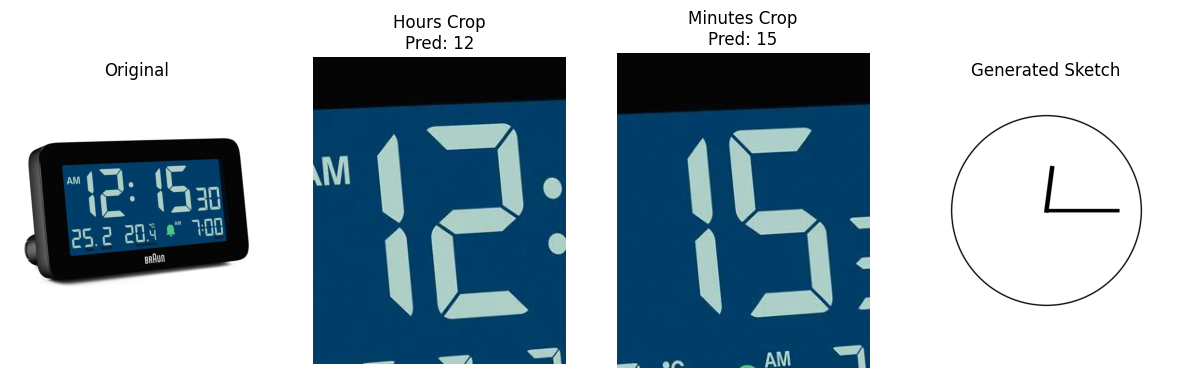

In [62]:
hh_val, mm_val, sketch = process_clock_image(DIGITAL_CLOCK_IMAGE)

## Analog clock (Version 1: conditional GAN)

In [63]:
try:
    yolo_detect_analog_clock_model = YOLO(YOLO_DETECT_ANALOG_CLOCK_PATH)
    print("YOLO Analog Clock Model loaded successfully.")
except Exception as e:
    print(f"Error loading YOLO: {e}")

YOLO Analog Clock Model loaded successfully.


In [64]:
class UNetDown(nn.Module):
    def __init__(self, in_size, out_size, normalize=True, dropout=0.0):
        super(UNetDown, self).__init__()
        layers = [nn.Conv2d(in_size, out_size, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_size))
        layers.append(nn.LeakyReLU(0.2))
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_size, out_size, dropout=0.0):
        super(UNetUp, self).__init__()
        layers = [
            nn.ConvTranspose2d(in_size, out_size, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(out_size),
            nn.ReLU(inplace=True),
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip_input):
        x = self.model(x)
        x = torch.cat((x, skip_input), 1)
        return x

class GeneratorUNet(nn.Module):
    def __init__(self, in_channels=6, out_channels=3):
        super(GeneratorUNet, self).__init__()
        self.down1 = UNetDown(in_channels, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        self.down6 = UNetDown(512, 512, dropout=0.5)
        self.down7 = UNetDown(512, 512, dropout=0.5)
        self.down8 = UNetDown(512, 512, normalize=False, dropout=0.5)
        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 512, dropout=0.5)
        self.up3 = UNetUp(1024, 512, dropout=0.5)
        self.up4 = UNetUp(1024, 512, dropout=0.5)
        self.up5 = UNetUp(1024, 256)
        self.up6 = UNetUp(512, 128)
        self.up7 = UNetUp(256, 64)
        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(128, out_channels, 4, padding=1),
            nn.Tanh(),
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        d8 = self.down8(d7)
        u1 = self.up1(d8, d7)
        u2 = self.up2(u1, d6)
        u3 = self.up3(u2, d5)
        u4 = self.up4(u3, d4)
        u5 = self.up5(u4, d3)
        u6 = self.up6(u5, d2)
        u7 = self.up7(u6, d1)
        return self.final(u7)

# --- הגדרות וטעינה ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# טעינת הגנרטור
generator = GeneratorUNet(in_channels=6, out_channels=3).to(device)
try:
    generator.load_state_dict(torch.load(SKETCH_GENERATOR_MODEL_PATH, map_location=device))
    print("Generator loaded successfully.")
except Exception as e:
    print(f"Error loading Generator: {e}")
generator.eval()


transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

Using device: mps
Generator loaded successfully.


In [65]:
def get_clock_crop(image, yolo_model, padding_pct=0.1):
    """
    מזהה שעון, מוסיף ריפוד של 10%, וחותך.
    מחזירה: התמונה החתוכה (PIL), והקואורדינטות של החיתוך (box) כדי שנוכל להדביק חזרה.
    """
    results = yolo_model(image, verbose=False)
    
    if not results or len(results[0].boxes) == 0:
        print("No clock detected. Using full image.")
        return image, (0, 0, image.width, image.height)

    box = results[0].boxes[0]
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    
    w = x2 - x1
    h = y2 - y1
    
    pad_w = w * padding_pct
    pad_h = h * padding_pct
    
    new_x1 = max(0, int(x1 - pad_w))
    new_y1 = max(0, int(y1 - pad_h))
    new_x2 = min(image.width, int(x2 + pad_w))
    new_y2 = min(image.height, int(y2 + pad_h))
    
    crop_box = (new_x1, new_y1, new_x2, new_y2)
    cropped_img = image.crop(crop_box)
    
    return cropped_img, crop_box

def denormalize(tensor):
    """ממיר טנסור מנורמל (-1 עד 1) לתמונת PIL"""
    image = tensor.cpu().clone().detach()
    image = image.squeeze(0)
    image = image * 0.5 + 0.5
    image = image.permute(1, 2, 0).numpy()
    image = np.clip(image, 0, 1)
    image = (image * 255).astype(np.uint8)
    return Image.fromarray(image)

def paste_generated_clock(original_image, generated_crop, crop_coords):
    """
    מדביק את השעון שנוצר חזרה לתוך התמונה המקורית.
    מבצע Resize כדי להתאים לגודל החיתוך המקורי.
    """
    x1, y1, x2, y2 = crop_coords
    target_w = x2 - x1
    target_h = y2 - y1
    

    resized_gen = generated_crop.resize((target_w, target_h), Image.LANCZOS)
    
    final_image = original_image.copy()
    final_image.paste(resized_gen, (x1, y1))
    
    return final_image

def run_first_analog_clock_pipeline(image_path, target_hh, target_mm):
    # 1. טעינת תמונה
    try:
        original_img = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Could not load image: {e}")
        return

    print(f"Processing image: {image_path} -> Target Time: {target_hh}:{target_mm:02d}")

    # 2. זיהוי וחיתוך (YOLO + 10% Padding)
    cropped_clock, crop_coords = get_clock_crop(original_img, yolo_detect_analog_clock_model, padding_pct=0.1)
    
    # שמירת המקור החתוך לתצוגה
    source_display = cropped_clock.copy()

    # 3. הכנה למודל cGAN
    # שינוי גודל ל-256x256 והמרה לטנסור
    src_tensor = transform(cropped_clock).unsqueeze(0).to(device)

    # 4. יצירת סרטוט היעד (Sketch)
    # המודל מצפה לקבל סרטוט בגודל 256x256
    # draw_analog_clock מחזיר numpy array, נמיר ל-PIL
    sketch_array = draw_analog_clock(target_hh, target_mm, return_array=True)
    sketch_pil = Image.fromarray(sketch_array).convert('RGB').resize((256, 256))
    skc_tensor = transform(sketch_pil).unsqueeze(0).to(device)

    # 5. הרצת הגנרטור
    with torch.no_grad():
        # שרשור המקור והסרטוט (6 ערוצים)
        model_input = torch.cat((src_tensor, skc_tensor), 1)
        generated_tensor = generator(model_input)

    # המרה חזרה לתמונה
    generated_clock_256 = denormalize(generated_tensor)

    # 6. החזרה לתמונה המקורית (Paste Back)
    final_result = paste_generated_clock(original_img, generated_clock_256, crop_coords)

    # --- תצוגה ---
    fig, ax = plt.subplots(1, 4, figsize=(20, 6))
    
    ax[0].imshow(original_img)
    ax[0].set_title("Original Image")
    ax[0].axis('off')

    ax[1].imshow(source_display)
    ax[1].set_title("Detected Clock (Input)")
    ax[1].axis('off')

    ax[2].imshow(sketch_pil)
    ax[2].set_title(f"Target Sketch ({target_hh}:{target_mm:02d})")
    ax[2].axis('off')

    ax[3].imshow(final_result)
    ax[3].set_title("Final Result (In-Place)")
    ax[3].axis('off')

    plt.show()
    
    return final_result

Processing image: ./test_analog_clock.jpg -> Target Time: 12:15


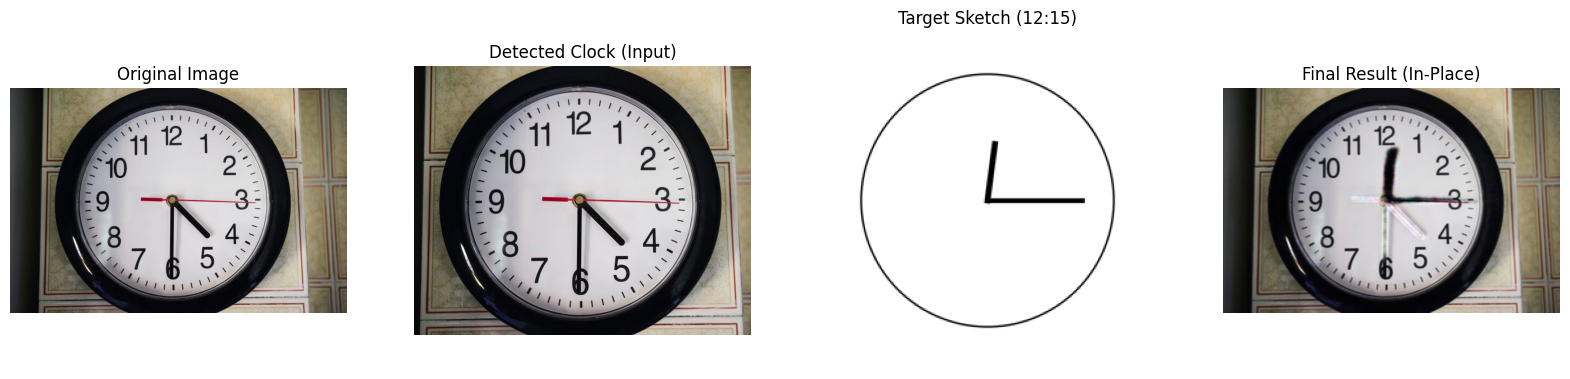

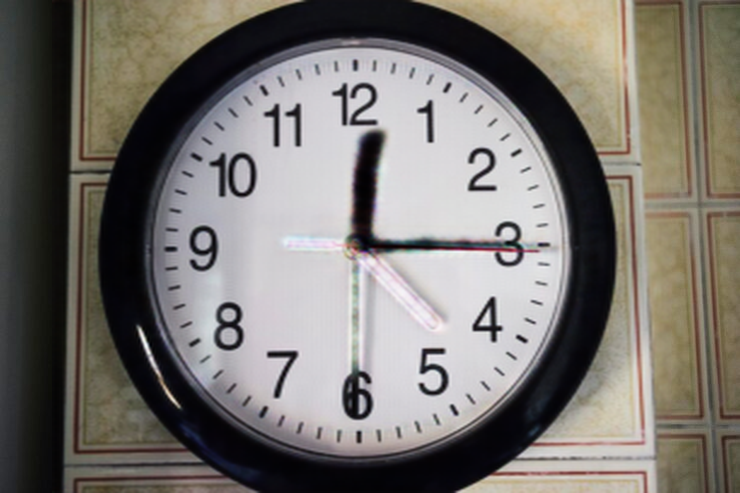

In [66]:
run_first_analog_clock_pipeline(ANALOG_CLOCK_IMAGE, target_hh=hh_val, target_mm=mm_val)


## Analog clock (Version 2: Mask-Guided Inpainting GAN)

In [67]:
class InpaintGenerator(nn.Module):
    def __init__(self, in_channels=4, out_channels=3): # 4 ערוצים בכניסה!
        super(InpaintGenerator, self).__init__()

        def down_block(in_feat, out_feat, normalize=True):
            layers = [nn.Conv2d(in_feat, out_feat, 4, 2, 1, bias=False)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_feat))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        def up_block(in_feat, out_feat, dropout=0.0):
            layers = [
                nn.ConvTranspose2d(in_feat, out_feat, 4, 2, 1, bias=False),
                nn.InstanceNorm2d(out_feat),
                nn.ReLU(inplace=True)
            ]
            if dropout:
                layers.append(nn.Dropout(dropout))
            return layers

        # Encoder
        self.down1 = nn.Sequential(*down_block(in_channels, 64, normalize=False))
        self.down2 = nn.Sequential(*down_block(64, 128))
        self.down3 = nn.Sequential(*down_block(128, 256))
        self.down4 = nn.Sequential(*down_block(256, 512, normalize=False)) # Bottleneck
        
        # Decoder
        self.up1 = nn.Sequential(*up_block(512, 256))
        self.up2 = nn.Sequential(*up_block(512, 128)) # Skip connection doubles input
        self.up3 = nn.Sequential(*up_block(256, 64))
        
        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(128, out_channels, 4, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        
        u1 = self.up1(d4)
        u2 = self.up2(torch.cat([u1, d3], 1)) 
        u3 = self.up3(torch.cat([u2, d2], 1)) 
        
        return self.final(torch.cat([u3, d1], 1))

In [68]:

def get_orientation_pca(mask):
    y_idxs, x_idxs = np.where(mask > 0)
    if len(x_idxs) == 0: return None, None
    pts = np.empty((len(x_idxs), 2), dtype=np.float64)
    pts[:, 0], pts[:, 1] = x_idxs, y_idxs
    mean, eigenvectors = cv2.PCACompute(pts, mean=None)
    return (mean[0, 0], mean[0, 1]), (eigenvectors[0, 0], eigenvectors[0, 1])

def find_intersection_pca(line1, line2):
    if line1[0] is None or line2[0] is None: return None
    p1, v1 = line1
    p2, v2 = line2
    A = np.array([[v1[0], -v2[0]], [v1[1], -v2[1]]])
    b = np.array([p2[0] - p1[0], p2[1] - p1[1]])
    try:
        x = np.linalg.solve(A, b)
        t = x[0]
        return (int(p1[0] + t * v1[0]), int(p1[1] + t * v1[1]))
    except np.linalg.LinAlgError:
        return None

def find_best_center_hybrid(img_rgb, mask_h, mask_m, mask_s):
    """
    משלבת Hough Circles עם חיתוך PCA למציאת מרכז יציב ומדויק.
    """
    h, w = img_rgb.shape[:2]
    img_center_geo = np.array([w/2, h/2])

    # 1. ניסיון: Hough Circles (עם פרמטרים מוקפדים)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gray_blurred = cv2.medianBlur(gray, 7)
    circles = cv2.HoughCircles(gray_blurred, cv2.HOUGH_GRADIENT, 1, h/4,
                               param1=100, param2=35, # סף רגישות בינוני
                               minRadius=int(h*0.35), maxRadius=int(h*0.55))
    
    hough_center = None
    if circles is not None:
        circles = np.uint16(np.around(circles))
        min_dist = float('inf')
        for i in circles[0, :]:
            center = np.array([i[0], i[1]])
            dist = np.linalg.norm(center - img_center_geo)
            # מסננים מעגלים שרחוקים מדי ממרכז התמונה (יותר מ-15% מהרוחב)
            if dist < min_dist and dist < w * 0.15:
                min_dist = dist
                hough_center = (int(i[0]), int(i[1]))

    # 2. ניסיון: חיתוך PCA (כגיבוי או לאימות)
    line_h = get_orientation_pca(mask_h)
    line_m = get_orientation_pca(mask_m)
    line_s = get_orientation_pca(mask_s)
    intersections = []
    for l1, l2 in [(line_h, line_m), (line_m, line_s), (line_s, line_h)]:
        pt = find_intersection_pca(l1, l2)
        if pt:
            dist = np.linalg.norm(np.array(pt) - img_center_geo)
            if dist < w * 0.2: # סינון חיתוכים לא הגיוניים
                intersections.append(pt)
    
    pca_center = None
    if intersections:
        # ממוצע של כל החיתוכים התקינים שנמצאו
        pca_center = (int(np.mean([p[0] for p in intersections])),
                      int(np.mean([p[1] for p in intersections])))

    # 3. קבלת החלטה חכמה
    # אם יש Hough טוב, נשתמש בו.
    if hough_center:
        # אם יש גם PCA והם קרובים זה לזה (פחות מ-5% מהרוחב), הממוצע שלהם הוא הכי מדויק.
        if pca_center and np.linalg.norm(np.array(hough_center) - np.array(pca_center)) < w * 0.05:
             print("Using Average of Hough and PCA centers.")
             return (int((hough_center[0]+pca_center[0])/2), int((hough_center[1]+pca_center[1])/2))
        print("Using Hough Center.")
        return hough_center

    # אם אין Hough אמין, ננסה את ה-PCA
    if pca_center:
        print("Hough failed, using PCA Intersection Center.")
        return pca_center

    # Fallback אחרון למרכז התמונה
    print("All methods failed, using Image Center.")
    return (w // 2, h // 2)

def get_angle_clockwise_from_12(mask, center_point):
    """
    מחשב את הזווית של המחוג ביחס לשעה 12:00, עם כיוון השעון.
    מחזיר ערך בין 0 ל-360.
    """
    if np.sum(mask) == 0: return 0
    
    # שלב השילוד (Skeleton) כדי למצוא את קו האמצע המדויק
    mask_uint8 = (mask * 255).astype(np.uint8)
    try:
        skeleton = cv2.ximgproc.thinning(mask_uint8)
    except:
        skeleton = mask_uint8 # Fallback
        
    y_idxs, x_idxs = np.where(skeleton > 0)
    if len(x_idxs) == 0: return 0

    # מציאת הטיפ (הנקודה הרחוקה ביותר מהמרכז)
    dists = (x_idxs - center_point[0])**2 + (y_idxs - center_point[1])**2
    max_idx = np.argmax(dists)
    
    tip_x = x_idxs[max_idx]
    tip_y = y_idxs[max_idx]
    
    # וקטור מהמרכז לטיפ
    vec_x = tip_x - center_point[0]
    vec_y = tip_y - center_point[1]
    
    # הטריק המתמטי: atan2(x, -y)
    # נותן 0 כשהוקטור מצביע למעלה (12:00)
    # וגדל ככל שזזים ימינה (עם כיוון השעון)
    angle_rad = math.atan2(vec_x, -vec_y)
    angle_deg = math.degrees(angle_rad)
    
    # נרמול לטווח [0, 360]
    if angle_deg < 0:
        angle_deg += 360
        
    return angle_deg

def time_to_degrees_cw(hh, mm, hand_type):
    """
    ממיר שעה לזווית (0=12:00, גדל עם כיוון השעון)
    """
    if hand_type == 'hour':
        # כל שעה היא 30 מעלות (360/12)
        # מוסיפים את החלק היחסי של הדקות (0.5 מעלות לדקה)
        return ((hh % 12) * 30) + (mm * 0.5)
    elif hand_type == 'minute':
        # כל דקה היא 6 מעלות (360/60)
        return mm * 6
    return 0

def get_orientation_pca(mask):
    """
    מוצא את כיוון המחוג ואת נקודת מרכז המסה שלו באמצעות PCA.
    מחזיר: (point_on_line, unit_vector)
    """
    # המרת נקודות המסכה לקואורדינטות (x, y)
    y_idxs, x_idxs = np.where(mask > 0)
    if len(x_idxs) == 0: return None, None

    # בניית מערך נתונים ל-PCA
    pts = np.empty((len(x_idxs), 2), dtype=np.float64)
    pts[:, 0] = x_idxs
    pts[:, 1] = y_idxs

    # ביצוע PCA
    # mean: מרכז המסה של הכתם
    # eigenvectors: הווקטורים הראשיים (הראשון הוא כיוון האורך)
    mean, eigenvectors = cv2.PCACompute(pts, mean=None)
    
    center_point = (mean[0, 0], mean[0, 1])
    direction_vector = (eigenvectors[0, 0], eigenvectors[0, 1]) # הווקטור המנורמל
    
    return center_point, direction_vector

def find_intersection_pca(line1, line2):
    """
    מוצא חיתוך בין שני קווים המוגדרים ע"י נקודה ווקטור כיוון.
    Line: (point, vector)
    """
    if line1[0] is None or line2[0] is None: return None
    
    p1, v1 = line1
    p2, v2 = line2
    
    # פתרון מערכת משוואות לינארית
    # P1 + t*V1 = P2 + u*V2
    # t*V1 - u*V2 = P2 - P1
    
    # בניית המטריצה
    A = np.array([[v1[0], -v2[0]], 
                  [v1[1], -v2[1]]])
    b = np.array([p2[0] - p1[0], 
                  p2[1] - p1[1]])
    
    try:
        x = np.linalg.solve(A, b)
        t = x[0]
        # נקודת החיתוך
        intersection_x = p1[0] + t * v1[0]
        intersection_y = p1[1] + t * v1[1]
        return (int(intersection_x), int(intersection_y))
    except np.linalg.LinAlgError:
        return None # קווים מקבילים

def find_center_by_hough_circles(img_rgb):
    """
    מוצא את מרכז השעון על ידי זיהוי המעגל החיצוני של המסגרת.
    שיטה זו הרבה יותר יציבה מחיתוך קווים.
    """
    # המרה לאפור וטשטוש להפחתת רעשים (קריטי ל-Hough)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gray = cv2.medianBlur(gray, 5)
    
    rows = gray.shape[0]
    
    # HoughCircles parameters:
    # dp=1: רזולוציית האקומולטור (1 = כמו תמונה מקורית)
    # minDist=rows/8: מרחק מינימלי בין מעגלים (מונע זיהוי כפול)
    # param1=100: סף עליון לזיהוי קצוות (Canny)
    # param2=30: סף לזיהוי מעגל (ככל שנמוך יותר, מזהה יותר מעגלים כולל שגויים)
    # minRadius, maxRadius: מגבלות גודל הגיוניות לשעון בתמונה
    circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, 1, rows / 8,
                               param1=100, param2=30,
                               minRadius=int(rows * 0.1), maxRadius=int(rows * 0.9))
    
    if circles is not None:
        circles = np.uint16(np.around(circles))
        
        # אנחנו מחפשים את המעגל שהכי קרוב למרכז התמונה (ההנחה היא שהשעון הוא הנושא המרכזי)
        img_center = np.array([img_rgb.shape[1] / 2, img_rgb.shape[0] / 2])
        best_center = None
        min_dist = float('inf')
        
        for i in circles[0, :]:
            center = np.array([i[0], i[1]])
            # radius = i[2]
            dist = np.linalg.norm(center - img_center)
            
            if dist < min_dist:
                min_dist = dist
                best_center = (int(i[0]), int(i[1]))
                
        return best_center
        
    return None

def find_center_multi_hand(mask_h, mask_m, mask_s, image_shape, max_dist_threshold=0.25):
    """
    מחשב את מרכז השעון על בסיס חיתוך של כל שלושת המחוגים.
    מסנן חיתוכים שנמצאים רחוק מדי ממרכז התמונה הגיאומטרי.
    
    max_dist_threshold: מרחק מקסימלי ממרכז התמונה (באחוזים מהגודל) כדי להיחשב תקין.
    """
    h, w = image_shape[:2]
    geo_center = np.array([w / 2, h / 2])
    max_pixel_dist = min(h, w) * max_dist_threshold # למשל, רבע רוחב תמונה

    # 1. חישוב קווים לינאריים לכל מחוג שזוהה
    line_h = get_line_params(mask_h) if np.sum(mask_h) > 0 else None
    line_m = get_line_params(mask_m) if np.sum(mask_m) > 0 else None
    line_s = get_line_params(mask_s) if np.sum(mask_s) > 0 else None

    intersections = []

    # 2. איסוף כל הזוגות האפשריים
    # רשימה של טאפלים: (קו 1, קו 2, משקל) - אפשר לתת משקל שונה לכל זוג אם רוצים
    pairs = [
        (line_h, line_m), # שעות-דקות
        (line_m, line_s), # דקות-שניות
        (line_s, line_h)  # שניות-שעות
    ]

    for l1, l2 in pairs:
        pt = find_lines_intersection(l1, l2)
        if pt is not None:
            # בדיקה: האם הנקודה נמצאת ב"אזור שהוא יחסית מרכז התמונה"?
            dist = np.linalg.norm(np.array(pt) - geo_center)
            if dist < max_pixel_dist:
                intersections.append(pt)

    # 3. קבלת החלטה
    if len(intersections) > 0:
        # ממוצע של כל החיתוכים התקינים שנמצאו
        avg_x = np.mean([p[0] for p in intersections])
        avg_y = np.mean([p[1] for p in intersections])
        return (int(avg_x), int(avg_y))
    
    # 4. Fallback (גיבוי) אם לא נמצאו חיתוכים
    # אם יש רק מחוג אחד או שהחיתוכים היו מחוץ למרכז, נחזור לשיטת ה"מרכז דינמי" הישנה (הנקודה הכי קרובה למרכז)
    # או פשוט נחזיר את מרכז התמונה
    print("No valid intersections found near center, falling back to dynamic centroid.")
    return find_dynamic_clock_center(mask_h, mask_m, image_shape) # אפשר להוסיף גם את mask_s כאן

def find_dynamic_clock_center(mask_hours, mask_minutes, image_shape):
    """
    פונקציית הגיבוי ממקודם - מוצאת את הפיקסל של המחוג שהכי קרוב למרכז
    """
    h, w = image_shape[:2]
    geo_center = np.array([w // 2, h // 2])
    combined_mask = np.maximum(mask_hours, mask_minutes) # אפשר להוסיף שניות
    y_idxs, x_idxs = np.where(combined_mask > 0)
    
    if len(x_idxs) == 0: return (w // 2, h // 2)

    points = np.stack((x_idxs, y_idxs), axis=1)
    dists = np.sum((points - geo_center)**2, axis=1)
    min_idx = np.argmin(dists)
    return (int(points[min_idx][0]), int(points[min_idx][1]))

def get_line_params(mask):
    """
    מקבל מסכה בינארית ומחזיר את פרמטרים של הקו המייצג אותה:
    נקודה על הקו (x,y) ווקטור כיוון (vx, vy).
    """
    # מציאת כל הנקודות הלבנות במסכה
    points = cv2.findNonZero(mask)
    
    if points is None:
        return None
    
    # חישוב הקו המתאים ביותר (Least Squares / M-estimator)
    # cv2.DIST_L2 הוא רגרסיה ריבועית סטנדרטית
    # param=0 נותן לאלגוריתם לבחור פרמטרים אופטימליים
    vx, vy, x0, y0 = cv2.fitLine(points, cv2.DIST_L2, 0, 0.01, 0.01)
    
    return (float(vx), float(vy), float(x0), float(y0))

def find_lines_intersection(line1, line2):
    """
    מוצא נקודת חיתוך בין שני קווים המיוצגים ע"י נקודה ווקטור.
    Line = (vx, vy, x0, y0)
    """
    if line1 is None or line2 is None:
        return None

    vx1, vy1, x1, y1 = line1
    vx2, vy2, x2, y2 = line2

    # פתרון מערכת משוואות לינארית למציאת החיתוך
    # משתמשים ב-Cross Product של וקטורי הכיוון
    # det = vx1 * vy2 - vy1 * vx2
    det = vx1 * vy2 - vy1 * vx2

    # אם הדטרמיננטה קרובה ל-0, הקווים מקבילים (אין חיתוך ברור)
    if abs(det) < 1e-6:
        return None

    # חישוב הפרמטר t עבור הקו הראשון: P = P1 + t * V1
    t = ((x2 - x1) * vy2 - (y2 - y1) * vx2) / det
    
    # הצבה כדי למצוא את נקודת החיתוך
    intersect_x = x1 + t * vx1
    intersect_y = y1 + t * vy1
    
    return (int(intersect_x), int(intersect_y))

def blend_images(background_rgb, foreground_rgba):
    """
    מבצע Alpha Blending בין רקע RGB לפורגראונד RGBA
    """
    # חילוץ ערוץ האלפא ונרמול ל-0-1
    alpha = foreground_rgba[:, :, 3] / 255.0
    alpha_3 = np.dstack((alpha, alpha, alpha))
    
    foreground_rgb = foreground_rgba[:, :, :3]
    
    # נוסחת הבלנדינג
    out = (foreground_rgb * alpha_3 + background_rgb * (1.0 - alpha_3))
    return out.astype(np.uint8)


In [69]:
def run_analog_clock_pipeline_v2(image_path, target_hh, target_mm, cgan_model, yolo_model):
    # --- טעינה ---
    img_pil = Image.open(image_path).convert('RGB')
    transform_resize = transforms.Resize((256, 256))
    img_resized = transform_resize(img_pil)
    img_cv = np.array(img_resized) 
    h, w, _ = img_cv.shape
    
    # --- שלב 1: יולו ואיסוף זיהויים ---
    dets_hours = []
    dets_minutes = []
    dets_seconds = []
    
    results = yolo_model(img_cv, conf=0.05, verbose=False) # סף נמוך כדי לתפוס הכל
    
    if results[0].masks is not None:
         masks_data = results[0].masks.data.cpu().numpy()
         classes = results[0].boxes.cls.cpu().numpy()
         confs = results[0].boxes.conf.cpu().numpy()
         
         for i, cls in enumerate(classes):
             m = cv2.resize(masks_data[i], (w, h), interpolation=cv2.INTER_NEAREST)
             current_conf = confs[i]
             
             if cls == 0: dets_hours.append((m, current_conf))
             elif cls == 1: dets_minutes.append((m, current_conf))
             elif cls == 2: dets_seconds.append((m, current_conf))

    # --- לוגיקה חדשה: גיבוי (Fallback) ---
    # אם לא נמצא מחוג דקות, אבל יש מחוג שניות -> השתמש בשניות כדקות
    if not dets_minutes and dets_seconds:
        print("Warning: Minute hand not found. Using Second hand as fallback.")
        dets_minutes = dets_seconds
        dets_seconds = [] # מרוקנים את השניות כדי שלא יטופלו פעמיים

    # פונקציית סינון (Winner Takes All + Union)
    def filter_detections(detections, shape):
        if not detections:
            return np.zeros(shape, dtype=np.uint8), np.zeros(shape, dtype=np.uint8)
        
        # מיון לפי ביטחון
        detections.sort(key=lambda x: x[1], reverse=True)
        
        # המסכה הטובה ביותר (להזזה)
        best_mask = detections[0][0]
        
        # כל המסכות מאוחדות (לניקוי)
        all_masks_combined = np.zeros(shape, dtype=np.uint8)
        for m, _ in detections:
            all_masks_combined = np.maximum(all_masks_combined, m)
            
        return best_mask, all_masks_combined

    # קבלת המסכות הסופיות
    best_mask_h, clean_mask_h = filter_detections(dets_hours, (h, w))
    best_mask_m, clean_mask_m = filter_detections(dets_minutes, (h, w))
    best_mask_s, clean_mask_s = filter_detections(dets_seconds, (h, w))

    # --- הכנת המסכה לניקוי (CGAN) ---
    # לוגיקה חדשה: המסכה הבינארית ללא מחוג השניות!
    # אנחנו מאחדים רק שעות ודקות.
    # (הערה: אם מחוג השניות הפך למחוג דקות בגלל ה-fallback, הוא נמצא ב-clean_mask_m ולכן כן יימחק, וזה תקין)
    full_mask_for_cleaning = np.maximum(clean_mask_h, clean_mask_m)
    
    full_mask_bin = (full_mask_for_cleaning > 0.5).astype(np.float32)
    
    # הרחבות למסכה
    kernel_cgan = np.ones((7, 7), np.uint8)
    dilated_mask_cgan = cv2.dilate(full_mask_bin, kernel_cgan, iterations=1) 
    
    kernel_inpaint = np.ones((11, 11), np.uint8)
    dilated_mask_inpaint = cv2.dilate(full_mask_bin, kernel_inpaint, iterations=1)

    mask_display = (dilated_mask_cgan * 255).astype(np.uint8)

    # --- שלב 2: חישוב מרכז ---
    center = find_best_center_hybrid(img_cv, best_mask_h, best_mask_m, best_mask_s)
    
    # --- שלב 3: CGAN + Inpaint ---
    transform_norm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    img_tensor = transform_norm(img_resized).to(device)
    mask_tensor = torch.from_numpy(dilated_mask_cgan).unsqueeze(0).to(device)
    mask_tensor = (mask_tensor - 0.5) / 0.5
    input_tensor = torch.cat([img_tensor, mask_tensor], dim=0).unsqueeze(0)
    
    with torch.no_grad():
        clean_bg_cgan = cgan_model(input_tensor).squeeze().permute(1, 2, 0).cpu().numpy()
        clean_bg_cgan = ((clean_bg_cgan * 0.5 + 0.5) * 255).clip(0, 255).astype(np.uint8)

    # ניקוי משלים (רק על שעות ודקות)
    inpaint_mask_uint8 = (dilated_mask_inpaint * 255).astype(np.uint8)
    clean_bg_final = cv2.inpaint(clean_bg_cgan, inpaint_mask_uint8, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

    # --- שלב 4: הרכבה ---
    final_output = clean_bg_final.copy()
    
    def process_hand_final(mask, img_src, current_bg, center_point, target_angle_cw=None):
        if np.sum(mask) == 0: return current_bg
        
        curr_angle_cw = get_angle_clockwise_from_12(mask, center_point)
        
        alpha = cv2.GaussianBlur((mask * 255).astype(np.uint8), (3, 3), 0)
        b, g, r = cv2.split(img_src)
        hand_rgba = cv2.merge([b, g, r, alpha])
        
        rotation_diff = 0 if target_angle_cw is None else target_angle_cw - curr_angle_cw
        
        M = cv2.getRotationMatrix2D(center_point, -rotation_diff, 1.0)
        rotated_hand = cv2.warpAffine(hand_rgba, M, (w, h), flags=cv2.INTER_LANCZOS4, borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0,0))
        return blend_images(current_bg, rotated_hand)

    angle_h = time_to_degrees_cw(target_hh, target_mm, 'hour')
    angle_m = time_to_degrees_cw(target_hh, target_mm, 'minute')

    # מדביקים שעות ודקות
    final_output = process_hand_final(best_mask_h, img_cv, final_output, center, angle_h)
    final_output = process_hand_final(best_mask_m, img_cv, final_output, center, angle_m)
    
    # הערה: מכיוון שהחרגנו את מחוג השניות מהניקוי, הוא נשאר ברקע.
    # אנחנו לא קוראים ל-process_hand_final עבור השניות כדי למנוע הדבקה כפולה (Ghosting).
    # (אלא אם כן הוא הפך לדקות ואז הוא טופל בשורה הקודמת).

    cv2.circle(final_output, center, 4, (255, 0, 0), -1)

    return img_cv, mask_display, clean_bg_final, final_output

Hough failed, using PCA Intersection Center.


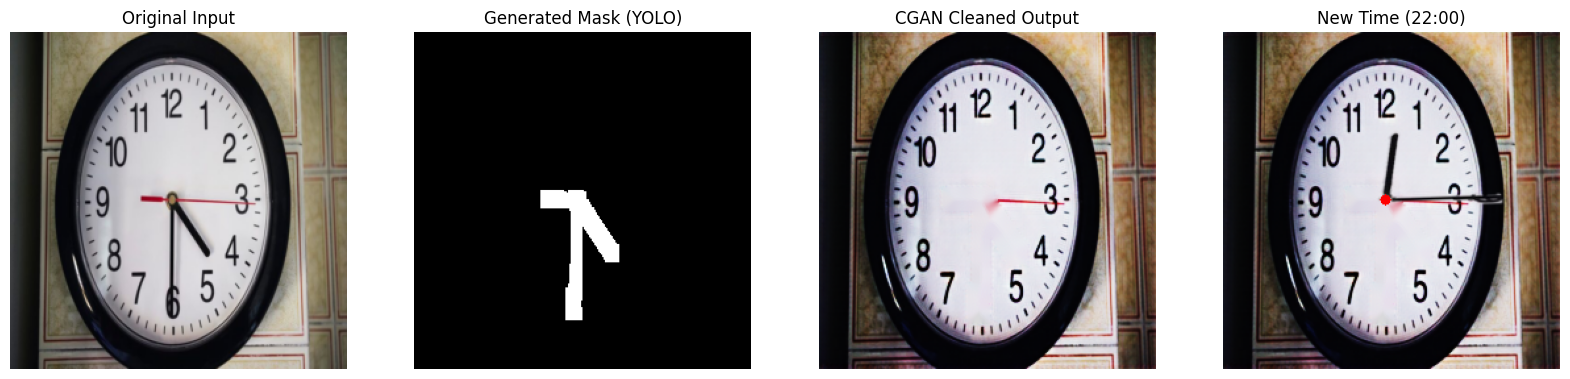

In [70]:
Igan = InpaintGenerator().to(device)
try:
    # מנסה לטעון ישירות ל-Device הנוכחי
    Igan.load_state_dict(torch.load(INPAINTINGS_MODEL_PATH, map_location=device))
except RuntimeError:
    # אם זה נכשל (קורה לפעמים במעבר מ-CUDA ל-MPS), טוענים ל-CPU ואז מעבירים
    print("Direct load failed, loading to CPU first...")
    Igan.load_state_dict(torch.load(INPAINTINGS_MODEL_PATH, map_location=torch.device('cpu')))
    Igan.to(device)
# 2. טעינת יולו (השלם את הטעינה שלך)
from ultralytics import YOLO
yolo = YOLO(YOLO_HANDS_MODEL_PATH) 


original, mask, clean, result = run_analog_clock_pipeline_v2(ANALOG_CLOCK_IMAGE, hh_val, mm_val, Igan, yolo)

# הגדרת פלוט רחב יותר ל-4 תמונות
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(original)
plt.title("Original Input")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(mask, cmap='gray') # הצגת המסכה בשחור לבן
plt.title("Generated Mask (YOLO)")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(clean)
plt.title("CGAN Cleaned Output")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(result)
plt.title("New Time (22:00)")
plt.axis('off')

plt.show()
